In [1]:
import os

import torch
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)


import torch

import numpy as np

import torch
import itertools
from tqdm import tqdm
import os
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed


import itertools


import torch
import os


import pandas as pd
from concurrent.futures import as_completed

from explanations import KRandom, Self
    
import logging
logging.getLogger().setLevel(logging.WARNING)



import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import multiprocessing
from tqdm import tqdm
import itertools
import pandas as pd
import traceback



logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')



    # return results_local
import argparse

# if __name__ == "__main__":
# parser = argparse.ArgumentParser()
# parser.add_argument("--explanation_type", type=str, required=True)
# parser.add_argument("--seed", type=int, required=False)

# args = parser.parse_args()


multiprocessing.set_start_method('spawn', force=True)   
torch.manual_seed(42)
from load_experiment_data import (
train_dataset_name,
test_dataset_name,
train_dataset_split,
test_dataset_split,
load_data_and_estimators,
explanation_types,
linear_coders,
explanation_k,
explanation_seed
)
train_dataset, test_dataset, estimators = load_data_and_estimators()


/root/.local/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/root/.local/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

influence_estimate_path: ./results/influence/DataInfEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test/estimate.parquet
dirname: ./results/influence/DataInfEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test
exists: True
influence_estimate_path: ./results/influence/BM25Estimator/1.5-0.75/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test/estimate.parquet
dirname: ./results/influence/BM25Estimator/1.5-0.75/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test
exists: True
influence_estimate_path: ./results/influence/LESSEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-o

In [2]:
_tsne_cache = {}

In [ ]:
import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# _tsne_cache = {}

def plot_tsne(gradients_groundset, methods=None, costs=None, vmax_percentile=95, markers=None):
    if isinstance(gradients_groundset, torch.Tensor):
        gradients_groundset = gradients_groundset.detach().cpu().numpy()
    if costs is not None and isinstance(costs, torch.Tensor):
        costs = costs.detach().cpu().numpy()
    xs = None
    ys = None
    cache_key = id(gradients_groundset)

    if cache_key in _tsne_cache:
        xs, ys, pca, tsne, x_reduced = _tsne_cache[cache_key]
    else:
        pca = PCA(n_components=min(50, gradients_groundset.shape[1]))
        x_reduced = pca.fit_transform(gradients_groundset)
        tsne = TSNE(n_components=2, perplexity=5, random_state=42, metric="cosine")
        x_tsne = tsne.fit_transform(x_reduced)
        xs, ys = x_tsne[:, 0], x_tsne[:, 1]
        _tsne_cache[cache_key] = (xs, ys, pca, tsne, x_reduced)

    plt.figure(figsize=(8, 6))

    # Plot all points with cost as hue
    if costs is not None:
        vmax = np.percentile(costs, vmax_percentile)
        scatter = plt.scatter(xs, ys, c=costs, s=25, cmap='viridis', vmax=vmax)
        plt.colorbar(scatter, label=f'Cost (capped at {vmax_percentile}th percentile)')
    else:
        plt.scatter(xs, ys, s=25, color='black', label="All Points")

    if costs is not None:
        max_idx = np.argmax(costs)
        plt.annotate(
            'Highest',
            xy=(xs[max_idx], ys[max_idx]),
            xytext=(xs[max_idx] + 5, ys[max_idx] + 5),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10,
            fontweight='bold',
            color='red',
        )
        min_idx = np.argmin(costs)
        plt.annotate(
            'Lowest',
            xy=(xs[min_idx], ys[min_idx]),
            xytext=(xs[min_idx] + 5, ys[min_idx] + 5),
            arrowprops=dict(facecolor='blue', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10,
            fontweight='bold',
            color='blue',
        )


    gradients_groundset = np.asarray(gradients_groundset)
    x_reduced = np.asarray(x_reduced)
    colors = ["black"] + list(plt.get_cmap('Set2').colors)
    markers = ['s', '^', 'D', '*', 'P', 'v']

    for (name, method), marker, color in zip(methods, markers, colors):
        method = np.asarray(method)

        method_pca = pca.transform(method)  #


        dists = np.linalg.norm(x_reduced[:, None, :] - method_pca[None, :, :], axis=2)  # shape (num_points, num_method_vectors)
        indices = np.argmin(dists, axis=0)  # shape (num_method_vectors,)

        plt.scatter(xs[indices], ys[indices], s=60, facecolor='none', marker=marker, edgecolor=color, label=name)
        if len(indices) > 2:  # ConvexHull needs at least 3 points
            hull_points = np.column_stack([xs[indices], ys[indices]])
            hull = ConvexHull(hull_points)
            plt.fill(hull_points[hull.vertices, 0], hull_points[hull.vertices, 1],
                    color=color, alpha=0.5, edgecolor=None)
    plt.title("t-SNE Projection")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.show()


In [4]:
import torch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon
import torch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
_tsne_cache = {}  # optional caching


def plot_tsne(
    gradients_groundset,
    methods=None,
    costs=None,
    vmax_percentile=95,
    perplexity=5,
    n_pca_components=50,
    facet_wrap=5,
    figsize=(5, 4)
):
    """
    Plot t-SNE of gradient dataset with method highlights using Seaborn facets,
    distinct markers per method, and convex hull "clouds".
    """

    # --- Convert tensors to numpy
    if isinstance(gradients_groundset, torch.Tensor):
        gradients_groundset = gradients_groundset.detach().cpu().numpy()
    if costs is not None and isinstance(costs, torch.Tensor):
        costs = costs.detach().cpu().numpy()

    # --- PCA + t-SNE caching
    cache_key = id(gradients_groundset)
    if cache_key in _tsne_cache:
        xs, ys, pca, tsne, x_reduced = _tsne_cache[cache_key]
    else:
        pca = PCA(n_components=min(n_pca_components, gradients_groundset.shape[1]))
        x_reduced = pca.fit_transform(gradients_groundset)
        tsne = TSNE(
            n_components=2, perplexity=perplexity, random_state=42, metric="cosine"
        )
        x_tsne = tsne.fit_transform(x_reduced)
        xs, ys = x_tsne[:, 0], x_tsne[:, 1]
        _tsne_cache[cache_key] = (xs, ys, pca, tsne, x_reduced)

    gradients_groundset = np.asarray(gradients_groundset)
    x_reduced = np.asarray(x_reduced)

    # --- Marker + color setup
    base_colors = list(plt.get_cmap("Set2").colors)
    markers = ["o", "s", "^", "D",  "P", "X", "v"]
    method_to_marker = {
        name: markers[i % len(markers)] for i, (name, _) in enumerate(methods)
    }
    method_to_color = {
        name: base_colors[i % len(base_colors)] for i, (name, _) in enumerate(methods)
    }

    # --- Prepare data for Seaborn facets
    facet_data = []
    hulls = []

    for (name, method) in methods:
        method = np.asarray(method)
        method_pca = pca.transform(method)
        dists = np.linalg.norm(x_reduced[:, None, :] - method_pca[None, :, :], axis=2)
        indices = np.argmin(dists, axis=0)

        for idx in indices:
            facet_data.append({
                "x": xs[idx],
                "y": ys[idx],
                "method": name,
                "marker": method_to_marker[name],
                "color": method_to_color[name],
            })

        # Store hull points
        if len(indices) > 2:
            hulls.append((name, np.column_stack([xs[indices], ys[indices]])))

    df = pd.DataFrame(facet_data)

    # --- Create FacetGrid
    g = sns.FacetGrid(df, col="method", col_wrap=facet_wrap,
                      height=figsize[1], sharex=True, sharey=True)

    def facet_scatter(data, color=None, **kwargs):
        name = data["method"].iloc[0]
        marker = method_to_marker[name]
        color = method_to_color[name]
        sns.scatterplot(
            data=data, x="x", y="y",
            s=70, edgecolor=color, facecolor="none",
            marker=marker, color=color
        )

    g.map_dataframe(facet_scatter)

    # --- Add convex hulls per facet
    for ax, (method_name, hull_points) in zip(g.axes.flatten(), hulls):
        hull = ConvexHull(hull_points)
        polygon = Polygon(
            hull_points[hull.vertices],
            closed=True,
            facecolor=method_to_color[method_name],
            alpha=0.25,
            edgecolor="none",
        )
        ax.add_patch(polygon)

    # --- Optional: add all points as cost background
    cmap = plt.get_cmap("viridis")
    if costs is not None:
        vmax = np.percentile(costs, vmax_percentile)
        norm = Normalize(vmin=np.min(costs), vmax=vmax)

        for ax in g.axes.flatten():
            ax.scatter(
                xs, ys, c=costs, s=20, cmap=cmap,
                norm=norm, alpha=0.7, linewidths=0
            )

        # Add shared colorbar
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])  # required for colorbar creation
        cbar = g.fig.colorbar(sm, ax=g.axes, orientation='vertical',
                              fraction=0.02, pad=0.02)
        cbar.set_label(f"Cost (capped at {vmax_percentile}th percentile)", rotation=90)

    # --- Labels and layout
    g.set_axis_labels("Dimension 1", "Dimension 2")
    g.set_titles(col_template="{col_name}")
    plt.tight_layout()
    plt.show()


In [5]:
# annotate test instance
# annotate highest and lowest scores

In [6]:
from explanations import TopKMostHelpful, Explanation,TopKMostHarmful, TopKMostInfluential,DIVINEMostHelpful, FacilityLocationMostHarmful,FacilityLocationMostInfluential


In [7]:
from abc import ABC, abstractmethod
import numpy
from numba import njit



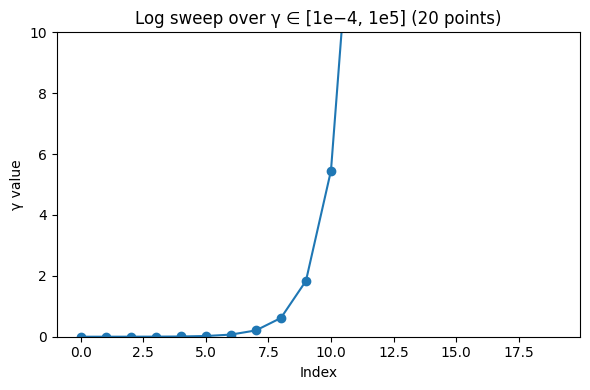

In [8]:
import numpy as np
import matplotlib.pyplot as plt

gamma_min_exp = -4     
gamma_max_exp = 5       
num_points = 20

# Correct log sweep
vals = np.logspace(gamma_min_exp, gamma_max_exp, num_points)

plt.figure(figsize=(6,4))
plt.plot(vals, marker='o')
plt.xscale('linear')
plt.ylim(0,10)
plt.title("Log sweep over γ ∈ [1e−4, 1e5] (20 points)")
plt.xlabel("Index")
plt.ylabel("γ value")
plt.tight_layout()
plt.show()


In [9]:
vals

array([1.00000000e-04, 2.97635144e-04, 8.85866790e-04, 2.63665090e-03,
       7.84759970e-03, 2.33572147e-02, 6.95192796e-02, 2.06913808e-01,
       6.15848211e-01, 1.83298071e+00, 5.45559478e+00, 1.62377674e+01,
       4.83293024e+01, 1.43844989e+02, 4.28133240e+02, 1.27427499e+03,
       3.79269019e+03, 1.12883789e+04, 3.35981829e+04, 1.00000000e+05])

In [10]:
# # 


# class DIVINEMostHelpful(DIVINE):
#     def __init__(self, document_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split,k=10, m=100, keep_gradients=False):
#         self.groundset_explanation = TopKMostHelpful(document_idx, estimator,train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=m)
#         super().__init__(document_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split,k=k, m=m, keep_gradients=keep_gradients)
#     @property
#     def description(self):
#         return f"{self.k} by DIVINE from Top-{self.groundset_explanation.k} most helpful (most negative scores)."
#     @property 
#     def importance_scores(self):
#         return -self.groundset_explanation.influence_estimate[self.groundset_explanation.documents]


# estimator = estimators[2] # DataInf
# explanation = DIVINEMostHelpful(0, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=10, m=100, keep_gradients=True)


# explanation.documents

In [11]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler


In [12]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler


################5##########


/tmp/ipykernel_48971/4264318975.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


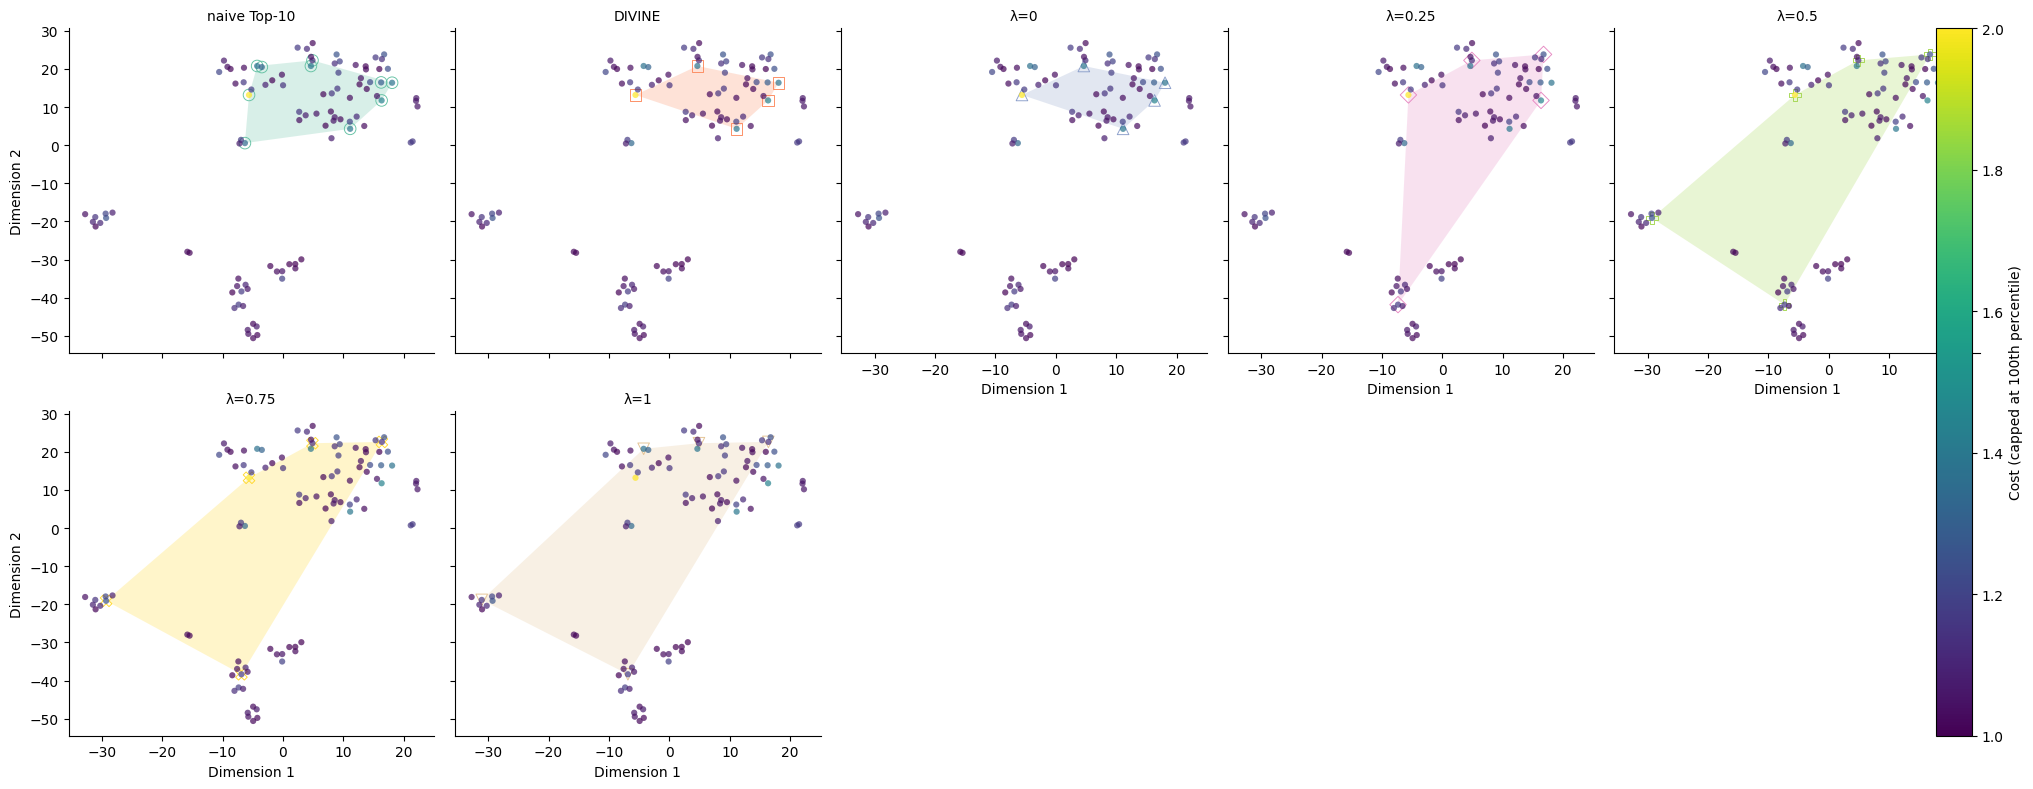

################10##########


/tmp/ipykernel_48971/4264318975.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


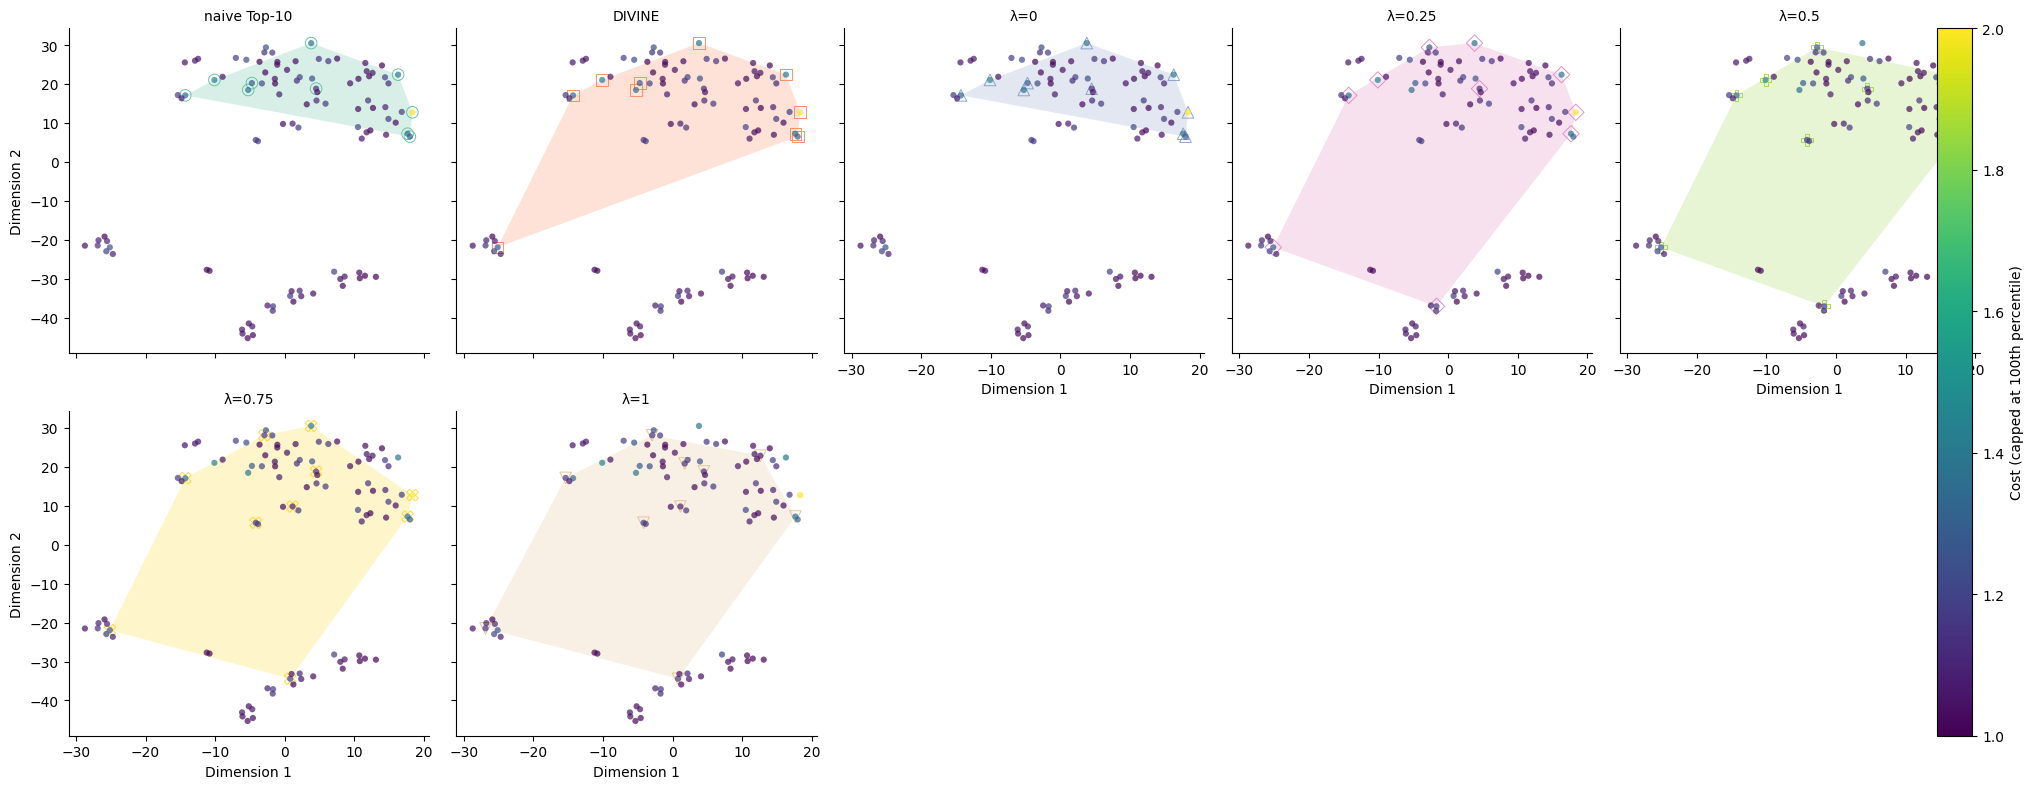

################25##########


/tmp/ipykernel_48971/4264318975.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


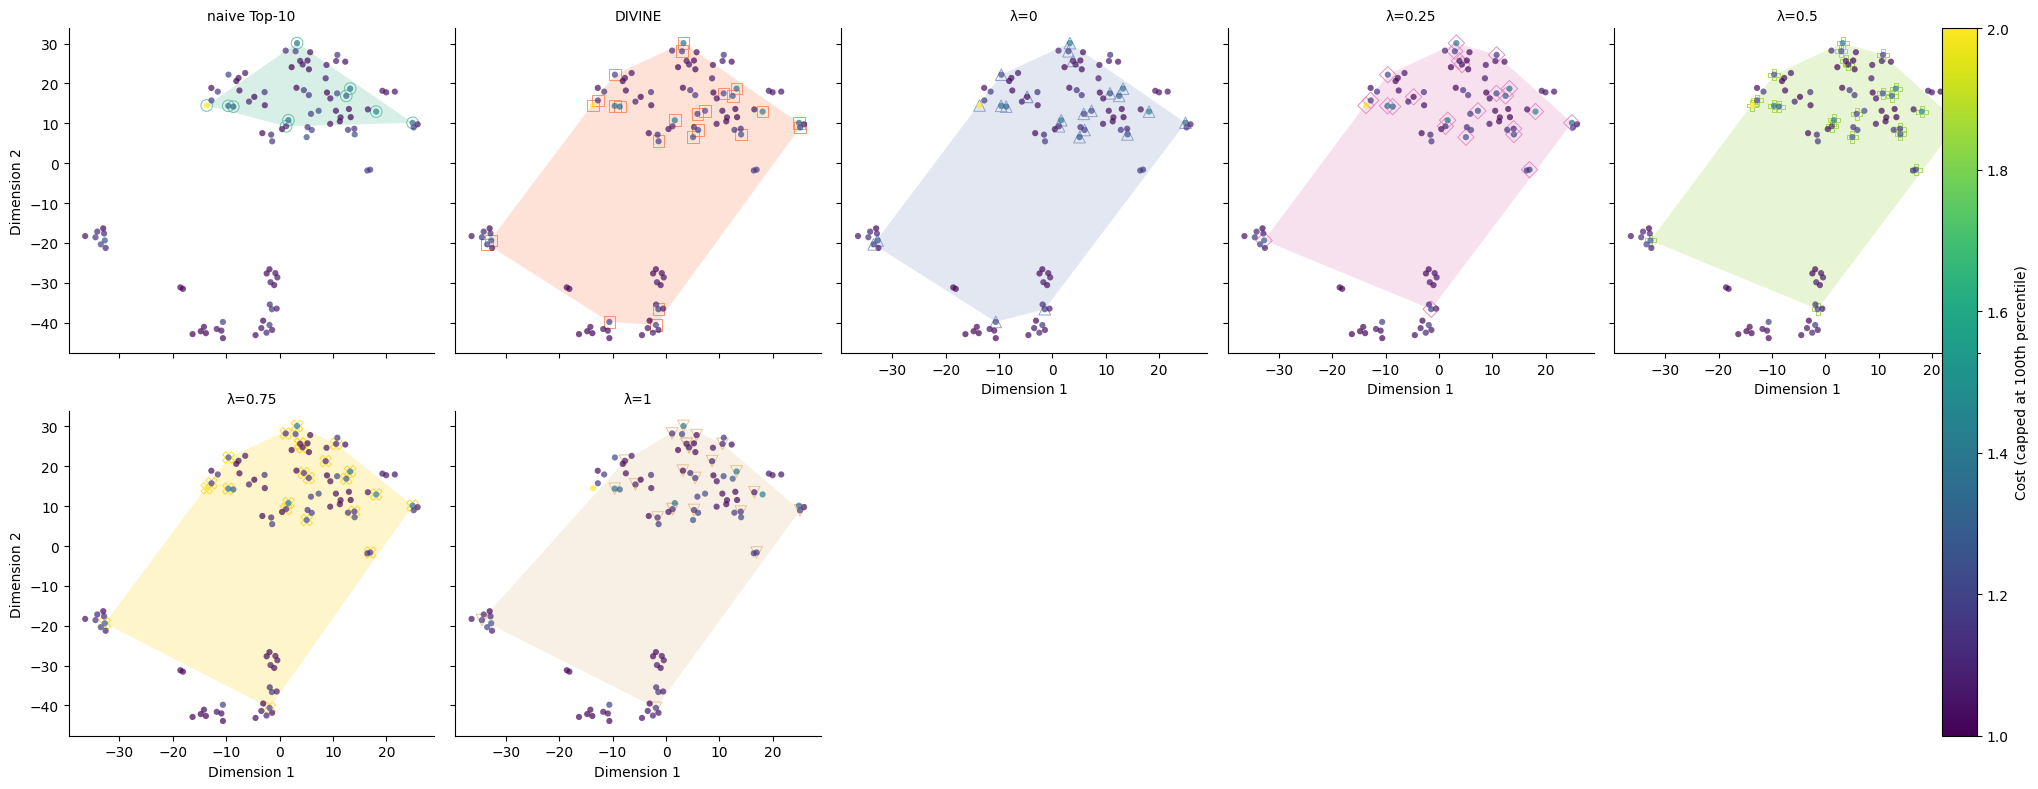

################5##########


QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull i Qt
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 1074598489  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width 5.1  Error-roundoff 1.2e-14  _one-merge 6.1e-14
  _near-inside 3.1e-13  Visible-distance 2.4e-14  U-max-coplanar 2.4e-14
  Width-outside 4.9e-14  _wide-facet 1.5e-13  _maxoutside 7.3e-14

The input to qhull appears to be less than 2 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p1(v3):   7.9    14
- p2(v2):    13    11
- p0(v1):   7.9    14

The center point is coplanar with a facet, or a vertex is coplanar
with a neighboring facet.  The maximum round off error for
computing distances is 1.2e-14.  The center point, facets and distances
to the center point are as follows:

center point    9.574     13.2

facet p2 p0 distance=    0
facet p1 p0 distan

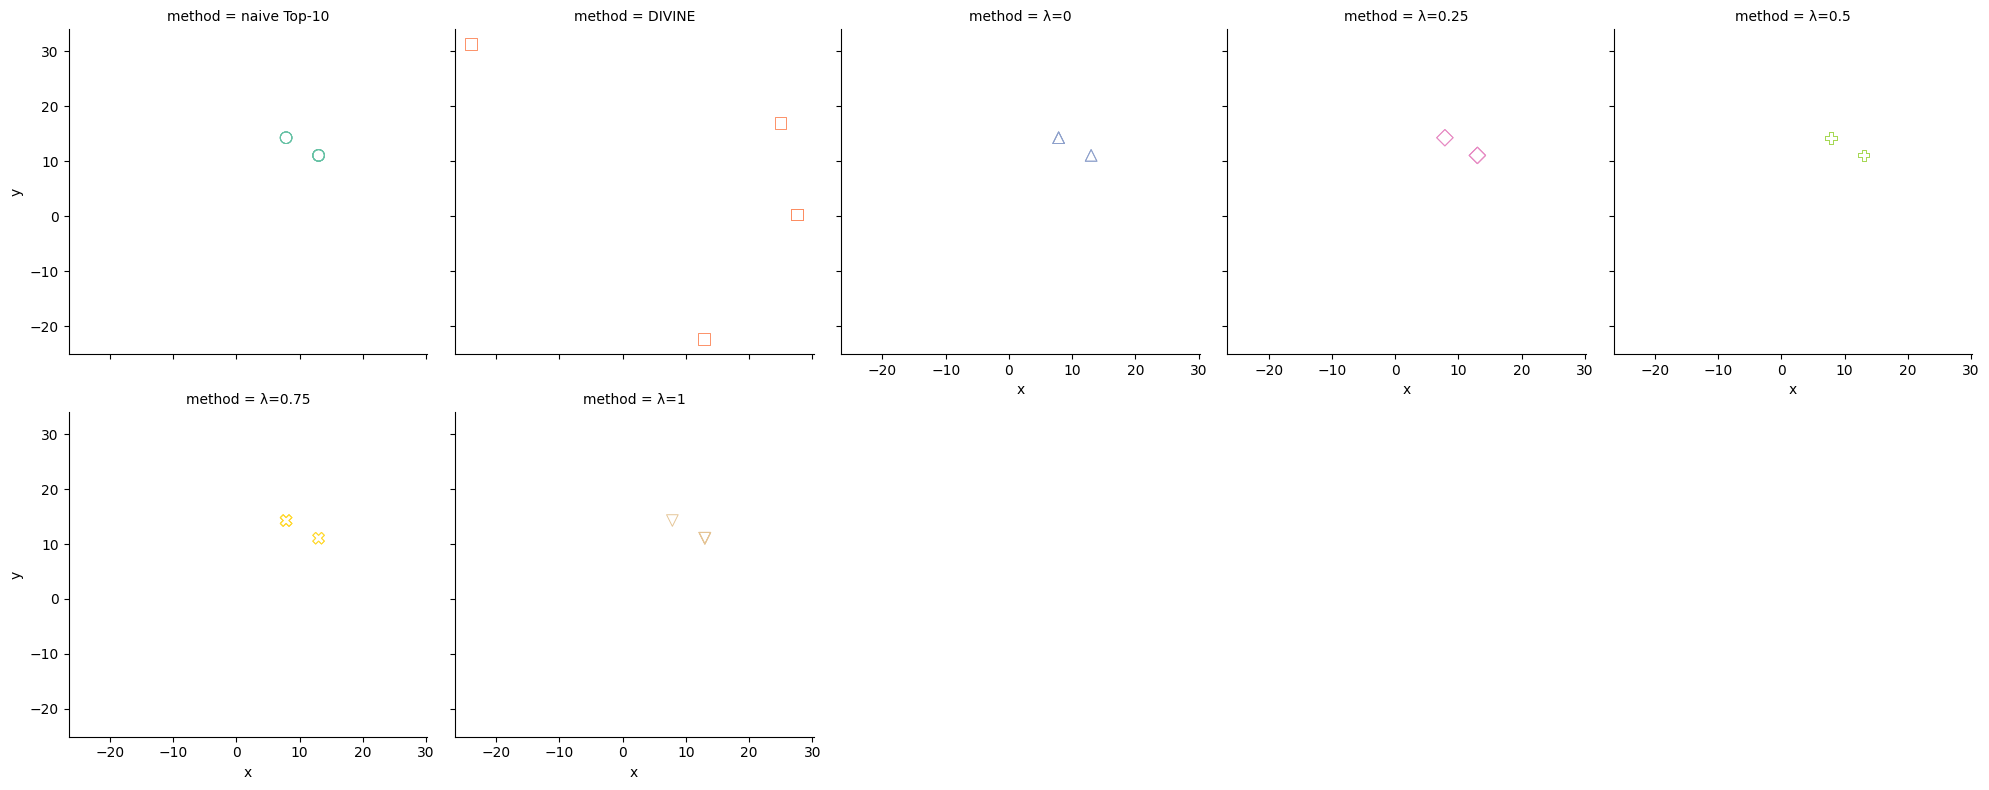

In [13]:
def get_gradients_selection(explanation):
    return torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, explanation.documents)).to(torch.float32).numpy()
for test_idx in [0,10,100]:
    
    for k in [5,10,25]:
        print(f"################{k}##########")
        estimator = estimators[2] # DataInf
        base_explanation = DIVINEMostHelpful(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, keep_gradients=True)


        gradients_groundset = torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, base_explanation.groundset_explanation.documents)).to(torch.float32).numpy()
        costs_groundset = base_explanation.importance_scores[base_explanation.groundset_explanation.documents]
        costs_groundset = MinMaxScaler((1, 2)).fit_transform(((costs_groundset.values.reshape(-1, 1)))).flatten()

        plot_tsne(gradients_groundset, costs=costs_groundset, methods=[
            ("naive Top-10", get_gradients_selection(TopKMostInfluential(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=10 ))), 
            ]+[("DIVINE", get_gradients_selection(DIVINEMostHelpful(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, keep_gradients=True)))]                  
             +[(f"λ={lambda_}", get_gradients_selection(FacilityLocationMostInfluential(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, lambda_=lambda_ , keep_gradients=True))) for lambda_ in [0,0.25,0.5,0.75,1]],\
                   vmax_percentile=100)

In [ ]:
def get_gradients_selection(explanation):
    return torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, explanation.documents)).to(torch.float32).numpy()
for test_idx in [0,10,100]:
    
    for k in [5,10,25]:
        print(f"################{k}##########")
        estimator = estimators[2] # DataInf
        base_explanation = FacilityLocationMostInfluential(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, lambda_=0 ,keep_gradients=True)


        gradients_groundset = torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, base_explanation.groundset_explanation.documents)).to(torch.float32).numpy()
        costs_groundset = base_explanation.costs[base_explanation.groundset_explanation.documents]
        costs_groundset = MinMaxScaler((1, 2)).fit_transform(((costs_groundset.values.reshape(-1, 1)))).flatten()

        plot_tsne(gradients_groundset, costs=costs_groundset, methods=[
            ("naive Top-10", get_gradients_selection(TopKMostInfluential(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=10 ))), 
            ]+[(f"λ={lambda_}", get_gradients_selection(FacilityLocationMostInfluential(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, lambda_=lambda_ , keep_gradients=True))) for lambda_ in [0,0.25,0.5,0.75,1]], vmax_percentile=100)

In [ ]:
asdfgsrdszerd

In [ ]:
import submodlib

In [ ]:
from submodlib.functions.facilityLocation import FacilityLocationFunction

In [ ]:
# obj1 = FacilityLocationFunction(n=A.shape[0], mode="clustered", data=A, metric="cosine", num_clusters=10)


In [ ]:
from submodlib import FeatureBasedFunction
from scipy.spatial import distance
from submodlib_cpp import FeatureBased

In [ ]:
# # import submodlib
# # import numpy as np

# # # 5 items, 3 features
# # features = np.array([
# #     [1, 0, 2],
# #     [0, 1, 1],
# #     [1, 1, 0],
# #     [0, 0, 1],
# #     [1, 2, 0]
# # ])

# # weights = np.array([0.5, 2.0, 1.0])  # prioritize feature 1

# # fb_func = submodlib.functions.featureBased.FeatureBasedFunction(
# #     n=5,
# #     features=features,
# #     numFeatures=3,
# #     sparse=False,
# #     featureWeights=weights,
# #     mode=FeatureBased.logarithmic
# # )

# # # Use lazy greedy maximization to select 2 items
# # subset = fb_func.maximize(optimizer="LazyGreedy", budget=2)
# # print(subset)
# rg8z90


In [ ]:
# obj1 = FeatureBasedFunction(n=A.shape[0], features=A, numFeatures=A.shape[1], sparse=False, mode=FeatureBased.logarithmic, featureWeights=costs)


In [ ]:
# # facilityLocation.py
# # Author: Vishal Kaushal <vishal.kaushal@gmail.com>
# import numpy as np
# import scipy
# from scipy import sparse
# from submodlib import SetFunction
# import submodlib_cpp as subcp
# from submodlib_cpp import FacilityLocation
# from submodlib_cpp import FacilityLocation2 
# from submodlib.helper import create_kernel, create_cluster_kernels
# #from memory_profiler import profile

# class WeightedFacilityLocationFunction(SetFunction):
# 	"""Implementation of the Facility Location submodular function (FL).

# 	Facility-Location function :cite:`mirchandani1990discrete` attempts to model representation, as in it tries to find a representative subset of items, akin to centroids and medoids in clustering. The Facility-Location function is closely related to k-medoid clustering. While diversity *only* looks at the elements in the chosen subset, representativeness also worries about their similarity with the remaining elements in the superset. Denote :math:`s_{ij}` as the similarity between data points :math:`i` and :math:`j`. We can then define 

# 	.. math::
# 			f(X) = \\sum_{i \\in V} \\max_{j \\in X} s_{ij} 
	
# 	For each data point :math:`i` in the ground set :math:`V`, we compute the representative from subset :math:`X` which is closest to :math:`i` and add these similarities for all data points. 

# 	In a more generic setting, the set whose representation is desired (we call it represented set :math:`U`) may be different from the set whose subset is desired (we call it ground set :math:`V`). The expression for Facility-Location function then becomes

# 	.. math::
# 			f(X) = \\sum_{i \\in U} \\max_{j \\in X} s_{ij} 

# 	An alternative clustered implementation of Facility Location assumes a clustering of all ground set items and then the function value is computed over the clusters as 

# 	.. math::
# 			f(X) = \\sum_{l \\in {1....k}} \\sum_{i \\in C_l} \\max_{j \\in X \\cap C_l} s_{ij} 

# 	Facility-Location is monotone submodular.
	
# 	.. note:: 
# 		This function requires computing a :math:`\\mathcal{O}(n^2)` similarity function. However, as shown in :cite:`wei2014fast`, we can approximate this with a nearest neighbor graph, which will require much less storage, and also can run much faster for large ground set sizes.

# 	Parameters
# 	----------

# 	n : int
# 		Number of elements in the ground set, must be > 0.

# 	mode : string
# 		Can be "dense", "sparse" or "clustered". It specifies whether the Facility Location function should operate in dense mode (using a dense similarity kernel) or sparse mode (using a sparse similarity kernel) or clustered mode (evaluating over clusters).
	
# 	separate_rep: bool, optional
# 		Specifies whether a set different from ground set should be used as represented set (whose representation is desired).
	
# 	n_rep : int, optional
# 		Number of elements in the represented set if separate_rep=True.
	
# 	sijs : numpy.ndarray or scipy.sparse.csr.csr_matrix, optional
# 		When separate_rep=False, this is the similarity kernel (dense or sparse) between the elements of the ground set, to be used for getting :math:`s_{ij}` entries as defined above. Shape of dense kernel in this case must be n X n. When separate_rep=True, mode must be "dense" and this is the dense similarity kernel between the represented set and the ground set. Shape in this case must be n_rep X n. When sijs is not provided, it is computed internally in C++ based on the following additional parameters.

# 	data : numpy.ndarray, optional
# 		Matrix of shape n X num_features containing the ground set data elements. data[i] should contain the num-features dimensional features of element i. Used to compute the similarity kernel. It is optional (and is ignored if provided) if sijs has been provided.

# 	data_rep : numpy.ndarray, optional
# 		Represented set data matrix (used to compute the dense similarity kernel) if separate_rep=True and when a similarity kernel is not provided.

# 	num_clusters : int, optional
# 		Number of clusters in the ground set. Used only if mode = "clustered". Must be provided if cluster_labels is provided. If cluster_labels is not provided, clusters will be created using sklearn's BIRCH method. In this case if num_clusters is not provided, BIRCH will produce an optimum number of clusters.

# 	cluster_labels : list, optional
# 		List of size n that contains cluster label for each item in the groundset. If mode=clustered and cluster_labels is not provided, clustering is done internally using sklearn's BIRCH.

# 	metric : str, optional
# 		Similarity metric to be used for computing the similarity kernel. Can be "cosine" for cosine similarity or "euclidean" for similarity based on euclidean distance. Default is "cosine".
	
# 	num_neighbors : int, optional
# 		Number of neighbors applicable for the sparse similarity kernel. Must not be provided if mode is "dense". Must be provided if either a sparse kernel is provided or is to be computed.
	
# 	create_dense_cpp_kernel_in_python : bool, optional
# 		Should be set to False ONLY when a similarity kernel is not provided and a CPP kernel is desired to be created in CPP. Default is True.
	
# 	pybind_mode : string, optional
# 		Specifies mode of pybind type conversion from Python to CPP. Can be one of *list*, *numpyarray* and *array*. *list* is the slowest, requiring converting numpy arrays to Python lists. *numpyarray" relies on automatic conversion. *array* leverages native data types and is the fastest. Default is "array".

# 	"""

# 	#@profile
# 	def __init__(self, n, mode, separate_rep=None, n_rep=None, sijs=None, data=None, data_rep=None, num_clusters=None, cluster_labels=None, metric="cosine", num_neighbors=None, create_dense_cpp_kernel_in_python=True, pybind_mode="array"):
# 		self.n = n
# 		self.n_rep = n_rep
# 		self.mode = mode
# 		self.metric = metric
# 		self.sijs = sijs
# 		self.data = data
# 		self.data_rep=data_rep
# 		self.num_neighbors = num_neighbors
# 		#self.partial = partial
# 		#self.ground_sub = ground_sub
# 		self.separate_rep=separate_rep
# 		self.clusters=None
# 		self.cluster_sijs=None
# 		self.cluster_map=None
# 		self.cluster_labels=cluster_labels
# 		self.num_clusters=num_clusters
# 		self.cpp_obj = None
# 		self.cpp_sijs = None
# 		self.cpp_ground_sub = None
# 		self.cpp_content = None
# 		self.effective_ground = None

# 		if self.n <= 0:
# 			raise Exception("ERROR: Number of elements in ground set must be positive")

# 		# if self.partial==True:
# 		# 	if type(self.ground_sub) == type(None) or len(self.ground_sub) == 0:
# 		# 		raise Exception("ERROR: Restricted subset of ground set not specified or empty for partial mode")
# 		# 	if self.mode == "clustered" or mode == "sparse":
# 		# 		raise Exception("clustered or sparse mode not supported if partial = True")
# 		# 	if not all(ele >= 0 and ele <= self.n-1 for ele in self.ground_sub):
# 		# 		raise Exception("Restricted subset of ground set contains invalid values")
# 		# 	if self.separate_rep == True:
# 		# 		raise Exception("Partial not supported if separate_rep = True")
		
# 		if self.mode not in ['dense', 'sparse', 'clustered']:
# 			raise Exception("ERROR: Incorrect mode. Must be one of 'dense', 'sparse' or 'clustered'")
		
# 		# if self.metric not in ['euclidean', 'cosine']:
# 		# 	raise Exception("ERROR: Unsupported metric. Must be 'euclidean' or 'cosine'")

# 		if self.separate_rep == True:
# 			if self.n_rep  is None or self.n_rep <=0:
# 				raise Exception("ERROR: separate represented intended but number of elements in represented not specified or not positive")	
# 			if self.mode != "dense":
# 				raise Exception("Only dense mode supported if separate_rep = True")
			
# 		if self.mode == "clustered":
# 			if type(self.cluster_labels) != type(None) and (self.num_clusters  is None or self.num_clusters <= 0):
# 				raise Exception("ERROR: Positive number of clusters must be provided in clustered mode when cluster_labels is provided")
# 			# if self.cluster_labels  is None or len(cluster_labels) != self.n:
# 			# 	raise Exception("ERROR: Cluster ID/label for each element in the ground set is needed")
# 			if type(self.cluster_labels) == type(None) and self.num_clusters is not None and self.num_clusters <= 0:
# 				raise Exception("Invalid number of clusters provided") 
# 			if type(self.cluster_labels) != type(None) and len(self.cluster_labels) != self.n:
# 				raise Exception("ERROR: cluster_labels's size is NOT same as ground set size")
# 			if type(self.cluster_labels) != type(None) and not all(ele >= 0 and ele <= self.num_clusters-1 for ele in self.cluster_labels):
# 				raise Exception("Cluster IDs/labels contain invalid values")

# 		if type(self.sijs) != type(None): # User has provided similarity kernel
# 			if create_dense_cpp_kernel_in_python == False:
# 				raise Exception("ERROR: create_dense_cpp_kernel_in_python is to be set to False ONLY when a similarity kernel is not provided and a CPP kernel is desired to be created in CPP")
# 			if type(self.sijs) == scipy.sparse.csr.csr_matrix:
# 				if num_neighbors is None or num_neighbors <= 0:
# 					raise Exception("ERROR: Positive num_neighbors must be provided for given sparse kernel")
# 				if mode != "sparse":
# 					raise Exception("ERROR: Sparse kernel provided, but mode is not sparse")
# 			elif type(self.sijs) == np.ndarray:
# 				if self.separate_rep is None:
# 					raise Exception("ERROR: separate_rep bool must be specified with custom dense kernel")
# 				if mode != "dense":
# 					raise Exception("ERROR: Dense kernel provided, but mode is not dense")
# 			else:
# 				raise Exception("Invalid kernel provided")
# 			#TODO: is the below dimensionality check valid for both dense and sparse kernels?
# 			if self.separate_rep == True:
# 				if np.shape(self.sijs)[1]!=self.n or np.shape(self.sijs)[0]!=self.n_rep:
# 					raise Exception("ERROR: Inconsistency between n_rep, n and no of rows, columns of given kernel")
# 			else:
# 				if np.shape(self.sijs)[0]!=self.n or np.shape(self.sijs)[1]!=self.n:
# 					raise Exception("ERROR: Inconsistentcy between n and dimensionality of given similarity kernel")
# 			if type(self.data) != type(None) or type(self.data_rep) != type(None):
# 				print("WARNING: similarity kernel found. Provided data matrix will be ignored.")
# 		else: #similarity kernel has not been provided
# 			if type(self.data) != type(None): 
# 				if self.separate_rep == True:
# 					if type(self.data_rep) == type(None):
# 						raise Exception("Represented data matrix not given")
# 					if np.shape(self.data)[0]!=self.n or np.shape(self.data_rep)[0]!=self.n_rep:
# 						raise Exception("ERROR: Inconsistentcy between n, n_rep and no of examples in the given ground data matrix and represented data matrix")
# 				else:
# 					if type(self.data_rep) != type(None):
# 						print("WARNING: Represented data matrix not required but given, will be ignored.")
# 					if np.shape(self.data)[0]!=self.n:
# 						raise Exception("ERROR: Inconsistentcy between n and no of examples in the given data matrix")
				
# 				if self.mode=="clustered":
# 					self.clusters, self.cluster_sijs, self.cluster_map = create_cluster_kernels(self.data.tolist(), self.metric, self.cluster_labels, self.num_clusters) #creates clusters if not provided
# 				else:
# 					if self.separate_rep==True: #mode in this case will always be dense
# 						if create_dense_cpp_kernel_in_python == True:
# 							self.sijs = np.array(subcp.create_kernel_NS(self.data.tolist(),self.data_rep.tolist(), self.metric))
# 					else:
# 						if self.mode == "dense":
# 							if self.num_neighbors  is not None:
# 								raise Exception("num_neighbors wrongly provided for dense mode")
# 							#self.num_neighbors = np.shape(self.data)[0] #Using all data as num_neighbors in case of dense mode
# 							if create_dense_cpp_kernel_in_python == True:
# 								self.sijs = np.array(subcp.create_square_kernel_dense(self.data.tolist(), self.metric))
# 						else:
# 							self.cpp_content = np.array(subcp.create_kernel(self.data.tolist(), self.metric, self.num_neighbors))
# 							val = self.cpp_content[0]
# 							#TODO: these two lambdas take quite a bit of time, worth optimizing
# 							#row = list(map(lambda arg: int(arg), self.cpp_content[1]))
# 							#col = list(map(lambda arg: int(arg), self.cpp_content[2]))
# 							# row = [int(x) for x in self.cpp_content[1]]
# 							# col = [int(x) for x in self.cpp_content[2]]
# 							row = list(self.cpp_content[1].astype(int))
# 							col = list(self.cpp_content[2].astype(int))
# 							self.sijs = sparse.csr_matrix((val, (row, col)), [n,n])
# 			else:
# 				raise Exception("ERROR: Neither ground set data matrix nor similarity kernel provided")
		
# 		# if self.partial==None:
# 		# 	self.partial = False
		
# 		if separate_rep==None:
# 			self.separate_rep = False
		
# 		# if self.partial==False: 
# 		self.cpp_ground_sub = {-1} #Provide a dummy set for pybind11 binding to be successful
		
# 		#Breaking similarity matrix to simpler native data structures for implicit pybind11 binding
# 		if self.mode=="dense" and create_dense_cpp_kernel_in_python == True:
# 			if pybind_mode == "list":
# 				self.cpp_sijs = self.sijs.tolist() #break numpy ndarray to native list of list datastructure
				
# 				if type(self.cpp_sijs[0])==int or type(self.cpp_sijs[0])==float: #Its critical that we pass a list of list to pybind11
# 																				#This condition ensures the same in case of a 1D numpy array (for 1x1 sim matrix)
# 					l=[]
# 					l.append(self.cpp_sijs)
# 					self.cpp_sijs=l

# 				self.cpp_obj = FacilityLocation(self.n, self.cpp_sijs, False, self.cpp_ground_sub, self.separate_rep)
# 			# elif pybind_mode == "memoryview":
# 			# 	self.cpp_obj = FacilityLocation(self.n, memoryview(self.sijs), False, self.cpp_ground_sub, self.separate_rep)
# 			elif pybind_mode == "numpyarray":
# 				self.cpp_obj = FacilityLocation(self.n, self.sijs, False, self.cpp_ground_sub, self.separate_rep)
# 			elif pybind_mode == "array32":
# 				# print("Kernel's type = ", self.sijs.dtype)
# 				self.sijs.astype('float32', copy=False)
# 				#self.cpp_obj = FacilityLocation2(self.n, self.sijs, False, {-1}, False);
# 				self.cpp_obj = FacilityLocation2()
# 				self.cpp_obj.pybind_init(self.n, self.sijs, False, {-1}, self.separate_rep);
# 			elif pybind_mode == "array64":
# 				# print("Kernel's type = ", self.sijs.dtype)
# 				self.sijs.astype('float64', copy=False)
# 				#self.cpp_obj = FacilityLocation2(self.n, self.sijs, False, {-1}, False);
# 				self.cpp_obj = FacilityLocation2()
# 				self.cpp_obj.pybind_init(self.n, self.sijs, False, {-1}, self.separate_rep);
# 			elif pybind_mode == "array":
# 				#self.cpp_obj = FacilityLocation2(self.n, self.sijs, False, {-1}, False);
# 				self.cpp_obj = FacilityLocation2()
# 				self.cpp_obj.pybind_init(self.n, self.sijs, False, {-1}, self.separate_rep);
# 			else:
# 				raise Exception("Invalid pybind mode!")
		
# 		elif self.mode=="dense" and create_dense_cpp_kernel_in_python == False:
# 			if self.separate_rep == True:
# 				self.cpp_obj = FacilityLocation(self.n, self.data.tolist(), self.data_rep.tolist(), True, self.metric)
# 			else:
# 				self.cpp_obj = FacilityLocation(self.n, self.data.tolist(), [[0.]], False, self.metric)
		
# 		elif self.mode=="sparse": #break scipy sparse matrix to native component lists (for csr implementation)
# 			self.cpp_sijs = {}
# 			self.cpp_sijs['arr_val'] = self.sijs.data.tolist() #contains non-zero values in matrix (row major traversal)
# 			self.cpp_sijs['arr_count'] = self.sijs.indptr.tolist() #cumulitive count of non-zero elements upto but not including current row
# 			self.cpp_sijs['arr_col'] = self.sijs.indices.tolist() #contains col index corrosponding to non-zero values in arr_val
# 			self.cpp_obj = FacilityLocation(self.n, self.cpp_sijs['arr_val'], self.cpp_sijs['arr_count'], self.cpp_sijs['arr_col'])
		
# 		elif self.mode=="clustered":
# 			l_temp = []
# 			#TODO: this for loop can be optimized
# 			for el in self.cluster_sijs:
# 				temp=el.tolist()
# 				if type(temp[0])==int or type(temp[0])==float: 
# 					l=[]
# 					l.append(temp)
# 					temp=l
# 				l_temp.append(temp)
# 			self.cluster_sijs = l_temp

# 			self.cpp_obj = FacilityLocation(self.n, self.clusters, self.cluster_sijs, self.cluster_map)

# 		#self.cpp_ground_sub=self.cpp_obj.getEffectiveGroundSet()
# 		#self.ground_sub=self.cpp_ground_sub
# 		self.effective_ground = self.cpp_obj.getEffectiveGroundSet()

In [ ]:
# obj1 = WeightedFacilityLocationFunction(n=A.shape[0], mode="clustered", data=A, metric="cosine", num_clusters=10)


In [ ]:
greedyList = obj1.maximize(budget=10,optimizer='NaiveGreedy', stopIfZeroGain=False, stopIfNegativeGain=False, verbose=False,  show_progress=False)
greedyList

In [ ]:
plot_tsne(A, greedyList=greedyList)

In [ ]:
estimators[0]

In [ ]:
import submodlib

In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_blobs
num_clusters = 10
cluster_std_dev = 4
points, cluster_ids, centers = make_blobs(n_samples=500, centers=num_clusters, 
                                          n_features=2, cluster_std=cluster_std_dev, center_box=(0,100), 
                                          return_centers=True, random_state=4)
data = list(map(tuple, points))
xs = [x[0] for x in data]
ys = [x[1] for x in data]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(xs, ys, s=25, color='black', label="Images")

In [ ]:
# get 6 data points belonging to cluster#1
import random
random.seed(1)
cluster1Indices = [index for index, val in enumerate(cluster_ids) if val == 1]
subset1 = random.sample(cluster1Indices, 6)
subset1xs = [xs[x] for x in subset1]
subset1ys = [ys[x] for x in subset1]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(subset1xs, subset1ys, s=25, color='red', label="Subset1")
set1 = set(subset1[:-1])

In [ ]:
# get 6 data points belonging to different clusters
subset2 = []
for i in range(6):
    #find the index of first point that belongs to cluster i
    diverse_index = cluster_ids.tolist().index(i)
    subset2.append(diverse_index)
subset2xs = [xs[x] for x in subset2]
subset2ys = [ys[x] for x in subset2]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(subset2xs, subset2ys, s=25, color='red', label="Subset2")
set2 = set(subset2[:-1])

In [ ]:
import numpy as np
dataArray = np.array(data)

In [ ]:
dataArray

In [ ]:
#start = time.process_time()
obj1 = FacilityLocationFunction(n=500, mode="dense", data=dataArray, metric="euclidean")
#print(f"Time taken by instantiation = {time.process_time() - start}")
print(f"Subset 1's FL value = {obj1.evaluate(set1)}")
print(f"Subset 2's FL value = {obj1.evaluate(set2)}")
print(f"Gain of adding another point ({subset1[-1]}) of same cluster to {set1} = {obj1.marginalGain(set1, subset1[-1])}")
print(f"Gain of adding another point ({subset2[-1]}) of different cluster to {set1} = {obj1.marginalGain(set1, subset2[-1])}")
obj1.setMemoization(set1)
print(f"Subset 1's Fast FL value = {obj1.evaluateWithMemoization(set1)}")
print(f"Fast gain of adding another point ({subset1[-1]}) of same cluster to {set1} = {obj1.marginalGainWithMemoization(set1, subset1[-1])}")
#start = time.process_time()
greedyList = obj1.maximize(budget=10,optimizer='NaiveGreedy', stopIfZeroGain=False, stopIfNegativeGain=False, verbose=False)
#print(f"Time taken by maximization = {time.process_time() - start}")
print(f"Greedy vector: {greedyList}")
greedyXs = [xs[x[0]] for x in greedyList]
greedyYs = [ys[x[0]] for x in greedyList]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(greedyXs, greedyYs, s=25, color='blue', label="Greedy Set")

In [ ]:
from submodlib.helper import create_kernel
#start = time.process_time()
K_dense = create_kernel(dataArray, mode='dense',metric='euclidean')
obj2 = FacilityLocationFunction(n=500, mode="dense", sijs = K_dense, separate_rep=False)
#print(f"Time taken by instantiation = {time.process_time() - start}")
print(f"Subset 1's FL value = {obj2.evaluate(set1)}")
print(f"Subset 2's FL value = {obj2.evaluate(set2)}")
print(f"Gain of adding another point of same cluster ({subset1[-1]}) to {set1} = {obj2.marginalGain(set1, subset1[-1])}")
print(f"Gain of adding another point of different cluster ({subset2[-1]}) to {set1} = {obj2.marginalGain(set1, subset2[-1])}")
obj2.setMemoization(set1)
print(f"Subset 1's Fast FL value = {obj2.evaluateWithMemoization(set1)}")
print(f"Fast gain of adding another point ({subset1[-1]}) of same cluster to {set1} = {obj2.marginalGainWithMemoization(set1, subset1[-1])}")
#start = time.process_time()
greedyList = obj2.maximize(budget=10,optimizer='NaiveGreedy', stopIfZeroGain=False, stopIfNegativeGain=False, verbose=False)
#print(f"Time taken by maximization = {time.process_time() - start}")
print(f"Greedy vector: {greedyList}")
greedyXs = [xs[x[0]] for x in greedyList]
greedyYs = [ys[x[0]] for x in greedyList]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(greedyXs, greedyYs, s=25, color='blue', label="Greedy Set")